# MTH/CMSE 314
# IC17: Singular value decomposition
### <p style="text-align: right;"> &#9989; **Mikel Good** </p>

#### Goals
- Understanding orthogonal matrices, especially that they have orthonormal columns (not just orthogonal).
- Understanding how to compute SVD for a matrix. 
- Using SVD for image compression.

#### Please read the following before you begin: 

- <font color=#641e16> We recommended that you complete the After-Class Assignments (ACs) before starting the In-Class Assignments (ICs),
    
- <font color=#641e16> Keep your lecture notes handy for easy reference.

- <font color=#641e16> Use class time to collaborate with your group and get help from instructors, as IC solutions will not be provided.

---
## 1. Orthogonal matrices

### Review
**Definition:** A *square* matrix is **orthogonal** if $A^{-1}=A^\top$.

Let $A$ be a square matrix. The following three statements are equivalent.

(a) $A$ is orthogonal. 

(b) The column vectors of $A$ form an orthonormal set. 

(c) The row vectors of $A$ form an orthonormal set.

(d) $A^{-1}$ is orthogonal. 

(e) $A^\top$ is orthogonal.

**Fact:** If $A$ is an orthogonal matrix, then we have $det(A)=\pm 1$.

---
&#9989; <font color=blue>**Do this:** Consider the vectors $u_1=\begin{bmatrix}1 \\ 0 \\ 0\end{bmatrix}, u_2=\begin{bmatrix}  0\\ \dfrac{1}{\sqrt{2}}\\ \dfrac{1}{\sqrt{2}}\end{bmatrix}, u_3=\begin{bmatrix}  0\\ \dfrac{1}{\sqrt{2}}\\ -\dfrac{1}{\sqrt{2}}   \end{bmatrix} $ that form a basis for $\mathbb R^3$. Answer the questions that follow.

<font color=blue> 1. Show that the vectors $u_1$, $u_2$, and $u_3$ are linearly independent.

In [63]:
import numpy as np
import sympy as sym

In [2]:
#Put your answer to the above here
RT2 = np.sqrt(2)

comb = np.array([
    [1, 0, 0],
    [0, 1/RT2, 1/RT2],
    [0, 1/RT2, -1/RT2]
])

sym.Matrix(comb).rref()[0]

Matrix([
[1, 0, 0],
[0, 1, 0],
[0, 0, 1]])

The vectors are linearly independent, as shown by the RREF above.

<font color=blue>2. Show that $u_1$, $u_2$, and $u_3$ are orthogonal.

In [3]:
#Put your answer to the above question here
u1 = comb[:,0]
u2 = comb[:,1]
u3 = comb[:,2]

comb_list = [u1, u2, u3]

for i in range(len(comb_list)):
    for j in range(len(comb_list)):
        if i != j:
            if np.dot(comb_list[i], comb_list[j]) != 0:
                print("The vectors {} and {} are not orthogonal".format(comb_list[i], comb_list[j]))
                break

<font color=blue>3. Show that $u_1$, $u_2$, and $u_3$ are unit vectors.

In [4]:
#Put your answer to the above question here
def unit_vec(vec):
    comp_sum = 0
    for i in vec:
        comp_sum += (i**2)

    result = np.sqrt(comp_sum)
    
    if np.isclose(1, result):
        return True
    return False

In [5]:
for vec in comb_list:
    if unit_vec(vec) == False:
        print("{} is not a unit vector".format(vec))
        break

<font color=blue>4. Express the vector $v = (7,5,-1)$ as a linear combination of the $u_1$, $u_2$, and $u_3$ basis vectors:

In [6]:
# Put your answer here
v = np.array([7, 5, -1])

comb_inv = np.linalg.inv(comb)

c = comb_inv @ v

print("v can be expressed as {}*u1 + {}*u2 + {}*u3".format(round(c[0], 3), round(c[1], 3), round(c[2]), 3))

v can be expressed as 7.0*u1 + 2.828*u2 + 4*u3


In [7]:
c[0]*u1 + c[1]*u2 + c[2]*u3

array([ 7.,  5., -1.])

---
&#9989; <font color=blue>**Do this:** Calculate the $P$ matrix for the following matrix $A$ such that $A=PDP^{-1}$.

In [8]:
A = np.matrix([[6,-2,-1],[-2,6,-1], [-1,-1,5]])
sym.Matrix(A)

Matrix([
[ 6, -2, -1],
[-2,  6, -1],
[-1, -1,  5]])

In [9]:
# Put your answer here
eigvecs = sym.Matrix(A).eigenvects()

eigvec1 = eigvecs[0][2][0]
eigvec2 = eigvecs[1][2][0]
eigvec3 = eigvecs[2][2][0]

In [10]:
vals = list(eigvec1) + list(eigvec2) + list(eigvec3)
P = np.zeros((3,3))

count = 0
for i in range(len(eigvec1)):
    for j in range(len(eigvec1)):
        P[j][i] = vals[count]
        if j != 2:
            count += 1
    count += 1

sym.Matrix(P)

Matrix([
[1.0, -0.5, -1.0],
[1.0, -0.5,  1.0],
[1.0,  1.0,  0.0]])

&#9989; <font color=blue>**Do this:** Check the columns of $P$. Are they orthogonal?

In [11]:
comb_list = [P[:,0], P[:,1], P[:,2]]

for i in range(len(comb_list)):
    for j in range(len(comb_list)):
        if i != j:
            if np.dot(comb_list[i], comb_list[j]) != 0:
                print("The vectors {} and {} are not orthogonal".format(comb_list[i], comb_list[j]))
                break

Yes, the columns **are orthogonal**

&#9989; <font color=blue>**Do this:** Show that in this special case (Where $A$ is symmetric) $A=PDP^\top$ with a special $P$.

In [12]:
# The sym.Matrix method of calculation was not arriving
# at the expected result
eigvals, P = np.linalg.eigh(A)

D = np.diag(eigvals)

result = (P@D) @ P.T

sym.Matrix(np.round(result, 10))

Matrix([
[ 6.0, -2.0, -1.0],
[-2.0,  6.0, -1.0],
[-1.0, -1.0,  5.0]])

In [13]:
sym.Matrix(A)

Matrix([
[ 6, -2, -1],
[-2,  6, -1],
[-1, -1,  5]])

<font size=+3>&#9998;</font> Yes, in this case $A=PDP^T$

&#9989; <font color=blue>**Question:** What do you need to do to invert an arbitrary $n \times n$ matrix?

<font size=+3>&#9998;</font> You would have to perform the Gaussian elimination method of the form $A|I$ and then reduce the left side to $I$, which would result in $I|A^{-1}$

&#9989; <font color=blue>**Question:** What do you need to do to invert an $n \times n$ **orthonormal** matrix?

<font size=+3>&#9998;</font> For an orthonormal matrix, $A^{-1} = A^T$

---
&#9989; <font color=blue>**Do this:** Find all the values of $\alpha$, if possible, such that the matrix $\begin{bmatrix}\dfrac{1}{2} & \dfrac{1}{\sqrt{2}}\\ \alpha& -\dfrac{1}{\sqrt{2}} \end{bmatrix}$ is orthogonal.

``` Import a photo of your calculations or type in latex. ```

&#9989; <font color=blue>**Do this:** Python has built-in functions to create orthogonal matrices. Use the following piece of code to create an orthogonal matrix and check that the matrix you got is indeed orthogonal.
    
```bash
import numpy as np
from scipy.stats import ortho_group

A = ortho_group.rvs(dim=5)
```

In [14]:
# Put your answer here
import numpy as np
from scipy.stats import ortho_group



A = ortho_group.rvs(dim=5)

result = A.T @ A
is_orthogonal = np.allclose(result, np.eye(5))

print("Is orthogonal: {}".format(is_orthogonal))

Is orthogonal: True


---
## 2. Singular Value Decomposition (SVD) 

In numerical linear algebra, we factorize matrices to facilitate efficient and/or accurate computations. There are many possible matrix decompositions including eigendecomposition, singular value decomposition (SVD), QR factorization, etc. Here we focus on the SVD, which is not restricted to diagonalizable (nor square) matrices. That is, SVD can be applied to square non-diagonalizable matrices, as well as to non-square matrices.

Now consider the non-square $n \times m$ matrix $A =\begin{bmatrix}4&11&14\\ 8&7&-2  \end{bmatrix}$.

In [15]:
import sympy as sym
A = np.matrix([[4, 11, 14], [8, 7, -2]])
sym.Matrix(A)

Matrix([
[4, 11, 14],
[8,  7, -2]])

The following code calculates $A^\top A=VDV^\top$:

In [16]:
sym.Matrix(A.T*A)

Matrix([
[ 80, 100,  40],
[100, 170, 140],
[ 40, 140, 200]])

In [17]:
eigvals, eigvecs = np.linalg.eig(A.T*A)
idx = eigvals.argsort()[::-1]   
eigvals = eigvals[idx]
eigvecs = eigvecs[:,idx]

V = eigvecs
sym.Matrix(V)

Matrix([
[-0.333333333333333, -0.666666666666666, -0.666666666666667],
[-0.666666666666667, -0.333333333333334,  0.666666666666667],
[-0.666666666666667,  0.666666666666667, -0.333333333333333]])

&#9989; <font color=blue>**Do this:** Calculate $AA^\top=UDU^\top$:

In [18]:
# Put your answer here
sym.Matrix(A @ A.T)

Matrix([
[333,  81],
[ 81, 117]])

In [19]:
eigvals, eigvecs = np.linalg.eig(A @ A.T)
idx = eigvals.argsort()[::-1]   
eigvals = eigvals[idx]
eigvecs = eigvecs[:,idx]

U = eigvecs
D = np.diag(eigvals)

In [20]:
sym.Matrix((U @ D) @ U.T)

Matrix([
[333.0,  81.0],
[ 81.0, 117.0]])

The following code calculates $\Sigma$ by putting the singular values on the diagonal of an $n \times m$ zero matrix: 

In [21]:
E = np.zeros(A.shape)

print(np.sqrt(np.abs(eigvals)))


for i in range(len(eigvals)):  # NOTE the difference of eigvals and eigval
    E[i,i] = np.sqrt(eigvals[i]) # instructor comment above is wrong, eigval is never defined
    
sym.Matrix(E)

[18.97366596  9.48683298]


Matrix([
[18.9736659610103,              0.0, 0.0],
[             0.0, 9.48683298050514, 0.0]])

&#9989; <font color=blue>**Do this:**  Verify that $A=U \Sigma V^\top$ or $A=-U\Sigma V^\top$. 

**Note:** $\sigma_i^2=\lambda_i$ is an eigenvalue of $A^TA$ and also $AA^T$. When we put the singular values in descending order, $\sigma_1\geq \sigma_2 \geq \dots \sigma_r>0$, they are uniquely determined.

In [22]:
# Put your answer here
sym.Matrix(A)

Matrix([
[4, 11, 14],
[8,  7, -2]])

In [23]:
U

matrix([[ 0.9486833 , -0.31622777],
        [ 0.31622777,  0.9486833 ]])

In [24]:
E

array([[18.97366596,  0.        ,  0.        ],
       [ 0.        ,  9.48683298,  0.        ]])

In [25]:
V.T

matrix([[-0.33333333, -0.66666667, -0.66666667],
        [-0.66666667, -0.33333333,  0.66666667],
        [-0.66666667,  0.66666667, -0.33333333]])

In [27]:
sym.Matrix((U@E) @ V.T)

Matrix([
[-4.0, -11.0, -14.0],
[-8.0,  -7.0,   2.0]])

&#9989; <font color=blue>**Do this:** Compare your results above with the answer from the built-in function ```np.linalg.svd()```.

In [28]:
# Put your answer here
U_np, S_np, VH_np = np.linalg.svd(A)

In [29]:
sym.Matrix(U_np)

Matrix([
[-0.948683298050514, -0.316227766016838],
[-0.316227766016838,  0.948683298050514]])

In [32]:
sym.Matrix(U)

Matrix([
[0.948683298050514, -0.316227766016838],
[0.316227766016838,  0.948683298050514]])

In [33]:
sym.Matrix(S_np)

Matrix([
[18.9736659610103],
[9.48683298050514]])

In [34]:
sym.Matrix(E)

Matrix([
[18.9736659610103,              0.0, 0.0],
[             0.0, 9.48683298050514, 0.0]])

In [35]:
sym.Matrix(VH_np)

Matrix([
[-0.333333333333333, -0.666666666666667, -0.666666666666667],
[ 0.666666666666667,  0.333333333333333, -0.666666666666667],
[-0.666666666666667,  0.666666666666667, -0.333333333333333]])

In [36]:
sym.Matrix(V)

Matrix([
[-0.333333333333333, -0.666666666666666, -0.666666666666667],
[-0.666666666666667, -0.333333333333334,  0.666666666666667],
[-0.666666666666667,  0.666666666666667, -0.333333333333333]])

In [39]:
S_np[0]

np.float64(18.973665961010283)

In [53]:
# changing the shape of S_np so that the matrix multiplication works
E_np = np.zeros(E.shape)
E_np[0,0] = S_np[0]
E_np[1,1] = S_np[1]

In [54]:
sym.Matrix((U_np @ E_np) @ VH_np)

Matrix([
[4.0, 11.0, 14.0],
[8.0,  7.0, -2.0]])

----

### 3. Using SVD for image compression

<img src="https://i.ibb.co/kVnpwf9/sparty.jpg" width="50%">


If you are running this notebook on your local machine, please download `sparty.jpg` from https://i.ibb.co/kVnpwf9/sparty.jpg and save it in the same folder as this notebook. If you are running this notebook on JupyterHub, you will need to first download `sparty.jpg` from the link, and then upload it to JupyterHub in the same folder as this notebook. 

After saving `sparty.jpg` in the same folder as this notebook, the following code will read the image file, discard the red and blue channels and pulls out the 'green' component of the image in a `numpy` matrix called `A`. We will treat this numpy array as a grayscale image. 

In [55]:
# Here are some libraries you may need to use
%matplotlib inline
import matplotlib.pylab as plt
import matplotlib.image as img
import numpy as np
import sympy as sym
import math
sym.init_printing()

Dimensions of image array: (1365, 2048, 3)


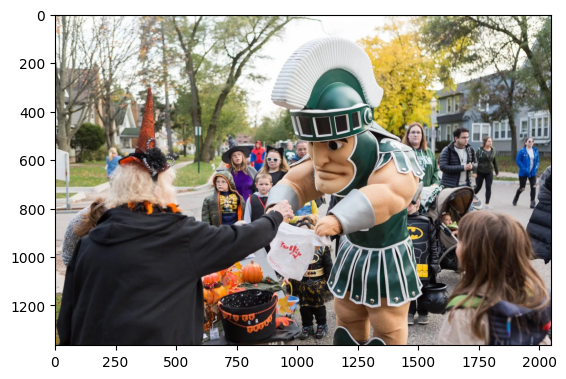

In [56]:
# load image as pixel array
A_RGB = img.imread('data_files/sparty.jpg')
print("Dimensions of image array:",A_RGB.shape)
plt.imshow(A_RGB);

Dimensions of green layer: (1365, 2048)


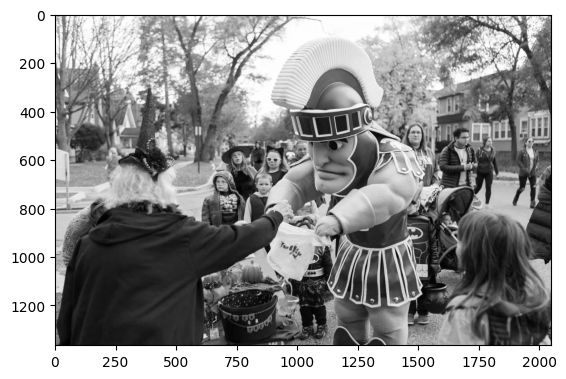

In [57]:
A = np.matrix(A_RGB[:,:,1].astype(float))
print("Dimensions of green layer:",A.shape)
plt.imshow(A, cmap='gray');

&#9989; <font color=blue>**Check:** To perform image compression, we will need to compute the SVD of the matrix `A`, which is a $1365 \times 2048$ matrix. Hopefully, your computer is fast enough to do this in a couple seconds. But if it isn't, uncomment out these lines of code in the cell below and run the cell to make a smaller version of this image.

In [58]:
#ONLY UNCOMMENT THESE LINES OF CODE AND RUN THIS CELL IF THE SVD STEP BELOW TAKES TOO LONG

#from PIL import Image
#A = np.array(Image.fromarray(A).resize((204,136)))
#print("Dimensions of green layer:",A.shape)
#plt.imshow(A, cmap='gray');

#ONLY UNCOMMENT THESE LINES OF CODE AND RUN THIS CELL IF THE SVD STEP BELOW TAKES TOO LONG

### Step 1: Singular Value Decomposition
The following code does a singular value decomposition (SVD) of the image matrix $A$. 

$$A = U\Sigma V^\top$$

**Note:** The following cell may take a while to run. Hopefully you should only need to do this once...

In [59]:
U, e, Vt = np.linalg.svd(A)
U = np.matrix(U)
Vt = np.matrix(Vt)
print("Dimensions of matrix with left singular vectors:",U.shape)
print("Dimensions of matrix with right singular vectors:",Vt.shape)
print("Dimensions of array with singular values:",e.shape)

Dimensions of matrix with left singular vectors: (1365, 1365)
Dimensions of matrix with right singular vectors: (2048, 2048)
Dimensions of array with singular values: (1365,)


<font color=blue> Remember that the numpy ```svd``` function returns an $m \times m$ matrix $U$, a vector of singular values $[\sigma_1,\ldots,\sigma_{\min(m,n)}]$ and an $n \times n$ matrix $V^T$. 

<font color=blue> First, the code below calculates the matrix $\Sigma$, which we will call $S$.

In [66]:
# Sigma matrix should be the same size as the original A matrix with mostly zero values
S = np.zeros(A.shape)

# The upper left diagonal of the Sigma matrix should be the singular values
S[:len(e), :len(e)] = np.diag(e)

 &#9989; <font color=blue>**Do this:** Verify the success of the decomposition by regenerating $A$ from the calculated components and comparing the regenerated $A$ to the original image $A$ using the numpy ```allclose``` function.

In [75]:
result = U @ S @ Vt

In [77]:
np.allclose(result, A)

True

### Step 2: Removing small singular values.

We are now going to make a new image but only keep the $r$ biggest singular values while setting all of the rest to zero. First we define a new vector (```s```) consisting of the first $r=10$ singular values:

In [78]:
r = 10
s = e[0:r]

Now let's remake the $\Sigma$ matrix using $s$. We will call this new $\Sigma$ matrix ```S``` (capital ```S```). We will use ```S``` to generate a new image and show the results:

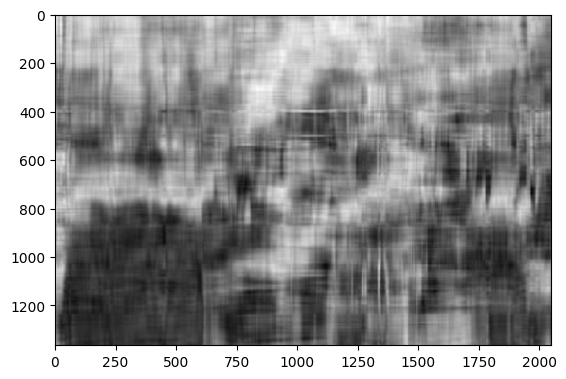

In [79]:
# Sigma matrix should be the same size as the original A matrix with mostly zero values
S = np.zeros(A.shape)

# The upper left diagonal of the Sigma matrix should be the singular values
S[:len(s), :len(s)] = np.diag(s)

#new image
A_new = U*S*Vt

plt.imshow(A_new, cmap='gray')

We can plot the difference between the original image and the image generated with only $r = 10$ singular values. This represents the error in the image at each pixel.

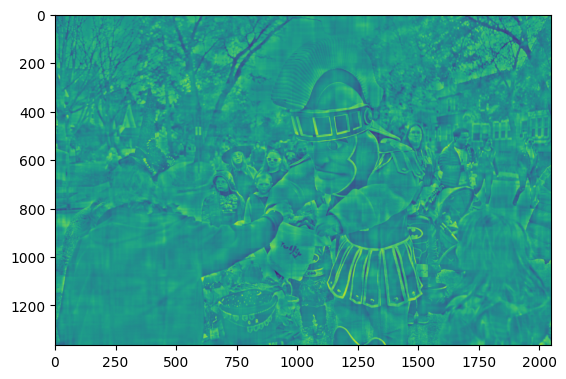

In [81]:
# Plot difference
plt.imshow(A-A_new)

The following calculates the relative mean squared error for the image. 

In [82]:
rel_mse = np.sum(np.array(A-A_new)**2)/np.sum(np.array(A)**2)
rel_mse

Although $10$ values seems like a good number, you can really see some distortion in the second image.  We want to find a better number for $r$. The following code makes a plot of the singular values to get an idea of the scale. Note that this plot has a $y$-axis that is logarithmic. 

Text(0, 0.5, 'singular value')

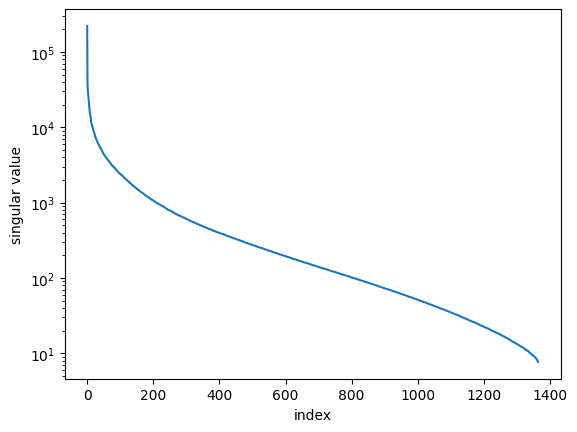

In [84]:
plt.plot(e)
plt.gca().set_yscale('log')
plt.xlabel('index')
plt.ylabel('singular value')


 &#9989; <font color=blue>**Do this:** Next, Modify the code in **Step 2** to pick a different value for $r$ such that it is hard to tell the difference between the new image and the original image. Try to make this $r$ as small as possible. Describe The procedure you used to come up with a new value for $r$.  

In [103]:
## Put your answer here
r = 100
s = e[:r]

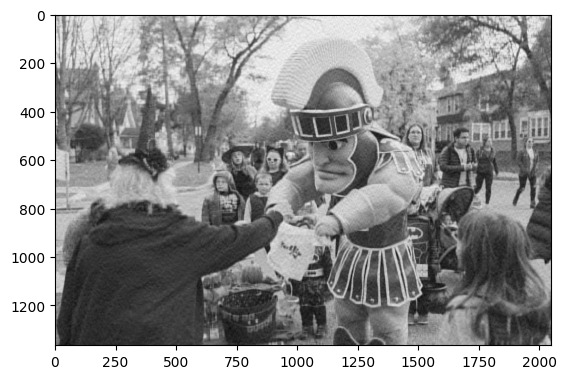

In [104]:
# Sigma matrix should be the same size as the original A matrix with mostly zero values
S = np.zeros(A.shape)

# The upper left diagonal of the Sigma matrix should be the singular values
S[:len(s), :len(s)] = np.diag(s)

#new image
A_new = U*S*Vt

plt.imshow(A_new, cmap="gray")

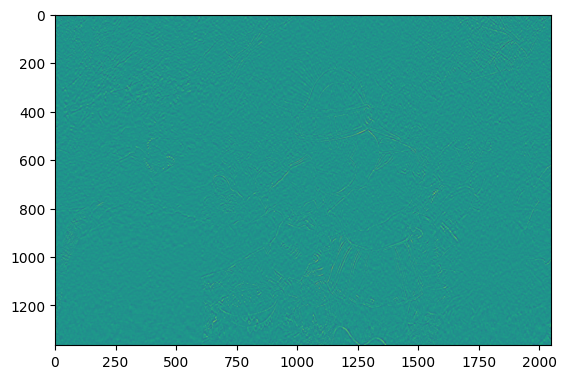

In [105]:
plt.imshow(A-A_new)

### Step 3: Compression

The reason we set a bunch of singular values to zero is to save memory.  However, so far we haven't saved anything.  We can make an estimate of storage of the original image $A$ by multiplying the number of the rows by the number of columns (i.e this is how many numbers we need to store to recreate the image):

In [110]:
orig_space = A.shape[0]*A.shape[1]
orig_space

Our new SVD representation uses the matrices `U`, `V`, and the vector `s`, which requires even more space to store the same information!

In [107]:
U.shape[0]*U.shape[1] + len(s) + Vt.shape[0] * Vt.shape[1]

However, the trick is that singular values of zero  don't add anything to the calculation and the zeros propagate though the math.  We can now make a new set of matrices, ```U_hat```,  ```S_hat``` and ```Vt_hat``` which are much smaller than ```U```, ```s```, ```Vt``` because we can remove the rows and columns that turn out to be zero in the math. 

True


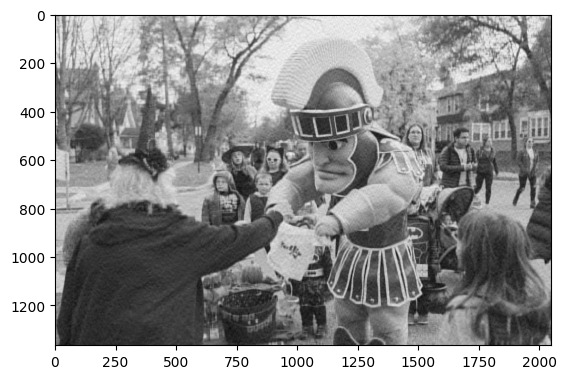

In [108]:
U_hat = np.matrix(U[:,:len(s)])
S_hat = np.diag(s)
Vt_hat = np.matrix(Vt[:len(s),:])

#Compressed image
A_compressed = U_hat*S_hat*Vt_hat
print(np.allclose(A_compressed,A_new)) # This is true if A_compressed = U_hat*S_hat*Vt_hat is close to A_new
plt.imshow(A_compressed, cmap='gray')

 &#9989; <font color=blue>**Do this:** How much space is required to store ```U_hat```, ```s```, and ```Vt_hat```? 

In [111]:
comp_space = U_hat.shape[0] * U_hat.shape[1] + len(s) + Vt.shape[0] * Vt.shape[1]

* &#9989; <font color=blue>**Do this:** Calculate the compression ratio, i.e. the amount of space required to store the original image divided by the amount of space required to store the SVD representation.

In [112]:
orig_space/comp_space

 &#9989; <font color=blue>**Do this:** If everything from above is correct, then we demonstrated that converting an image to a reduced SVD format will save in memory storage. Describe at least two disadvantages of using SVD for image compression.

Even the numpy svd function takes a long time to run. This means that we have to wait to write the files to disk.\
Although the images look similar we loose data. This data may be important especially if used in science.\
Recovery of the image requires a specific algorithm. This requires programs to understand the data format.\
The way we are picking  is subjective.\
The algorithm may need to be changed to automatically select the "best " and that may not look correct or take additional algorithmic complexity.

----
# _Time permitting_

<a name="Pseudoinverse"></a>
## Pseudoinverse of a matrix

In this class we often talk about solving problems of the form:

$$Ax = b$$

Currently we have determined that this problem becomes very nice when the $n \times n$ matrix $A$ has an inverse. We can easily multiply each side by the inverse:

$$A^{-1}Ax = A^{-1}b$$

Since $A^{-1}A = I$ the solution for $x$ is simply:

$$x = A^{-1}b$$

Now, let us consider a a more general problem where the $m \times n$ matrix $A$ is not square, i.e. $m \neq n$ and its rank $r$ maybe less than $m$ and/or $n$.  In this case we want to find a Pseudoinverse (which we denote as $A^+$) which acts like an inverse for a non-square matrix. In other words we want to find an $A^+$ for $A$ such that:

$$A^+A \approx I$$

Assuming we can find the $n \times m$ matrix $A^+$, we should then be able to solve for $x$ as follows:

$$Ax = b$$
$$A^+Ax = A^+b$$
$$x \approx A^+b$$

### How do we know there is a Pseudoinverse
Assuming the general case of a $m\times n$ matrix $A$ where its rank $r$ maybe less than $m$ and/or $n$ ($r\leq m$ and $r\leq n$). We can conclude the following about the fundamental spaces of $A$:
- The rowspace of $A$ is in $R^n$ with dimension  


In [ ]:
# what dimension?

- The columnspace of $A$ is in $R^m$ with dimension 

In [ ]:
# what dimension?

- The nullspace of $A$ is in $R^n$ with dimension 

In [ ]:
# what dimension?

- The nullspace of $A^T$ is in $R^m$ with dimension 

In [ ]:
# what dimension?

Because the rowspace of $A$ and the column space $A$ have the same dimension then $x\mapsto Ax$ is a the one-to-one and onto mapping from the row space to the columnspace. In other words:
- For any $x$ in the rowspace, we have that $Ax$ is one point in the columnspace. If $x'$ is another point in the row space different from $x$, we have $Ax\neq Ax'$ (The mapping is one-to-one). 
- For any $y$ in the columnspace, we can find $x$ in the rowspace such that $Ax=y$ (The mapping is onto). 

The above is not really a proof but hopefully there is sufficient information to convince yourself that this is true. 

### How to compute pseudoinverse
We want to find the $n\times m$ matrix $A^+$ that maps from columnspace to the rowspace of $A$, and $x=A^+Ax,$ if $x$ is in the rowspace. 

+ Let's apply SVD on $A$: $$A= U\Sigma V^\top,$$
where $U$ is a $m\times m$ matrix, $V^\top$ is a $n\times n$ matrix, and $\Sigma$ is a diagonal $m\times n$ matrix. 
We can decompose the matrices as 
$$A = \begin{bmatrix}\vdots & \vdots \\ U_1 & U_2 \\ \vdots &\vdots\end{bmatrix} \begin{bmatrix}\Sigma_1 & 0 \\ 0 & 0\end{bmatrix}  \begin{bmatrix}\cdots & V_1^\top & \cdots \\ \cdots & V_2^\top &\cdots \end{bmatrix}.$$
Here $U_1$ is of $m\times r$, $U_2$ is of $m\times (m-r)$, $\Sigma_1$ is of $r\times r$, $V_1^\top$ is of $r\times n$, and $V_2^\top$ is of $(n-r)\times n$. 
    + The columnspace of $U_1$ is the columnspace of $A$, and columnspace of $U_2$ is the nullspace of $A^\top$. 
    + The rowspace of $V_1$ is the rowspace of $A$, and rowspae of $V_2$ is the nullspace of $A$.

+ If $x$ is in the rowspace of $A$, we have that $V_2^\top x=0$. We have $Ax = U_1\Sigma_1 V_1^\top x$.
    + If we define a matrix $B=V_1\Sigma_1^{-1}U_1^\top$, we have that $BAx=V_1\Sigma_1^{-1}U_1^\top U_1\Sigma_1 V_1^\top x=V_1V_1^\top x$. That is $BAx=x$ is $x$ is in the rowspace of $A$. 
    
+ The matrix $B$ is the pseudoinverse of matrix $A$. 
$$A^+ = V_1\Sigma_1^{-1}U_1^\top$$
$$A^+ = \begin{bmatrix}\vdots & \vdots \\ V_1 & V_2 \\ \vdots &\vdots\end{bmatrix} \begin{bmatrix}\Sigma_1^{-1} & 0 \\ 0 & 0\end{bmatrix}  \begin{bmatrix}\cdots & U_1^\top & \cdots \\ \cdots & U_2^\top &\cdots \end{bmatrix}.$$

**Example 1:** Let $$A=\begin{bmatrix}1 & 0 & 1\\ 1 & 2 & 3\end{bmatrix}$$
we know that 
$r=m=2$ and $n=3$.

In [ ]:
A = np.matrix([[1,0,1],[1,2,3]])

**<font color=red>Question:</font>**  Calculate the pseudoinverse $A^+$ of $A$ using the ```numpy.linalg``` function ```pinv```:</mark>

In [12]:
#Put your answer here

**<font color=red>Question:</font>**  Compute $AA^+$ and $A^+A$</mark>.

In [13]:
#Put your answer here

**<font color=red>Question:</font>** If $x$ is in the nullspace of $A$ what is the effect of $A^+Ax$?</mark>

<font size=+3>&#9998;</font> _put your answer here_ 

**<font color=red>Question:</font>**  If $x$ is in the rowspace of $A$ what is the effect of $A^+Ax$?</mark>

<font size=+3>&#9998;</font> _put your answer here_ 

---
### Left inverse is pseudoinverse

We can compute the left inverse of $A$ if $r=n\leq m$. In this case, we may have more rows than columns, and the matrix $A$ has full column rank. 

In this case, the SVD of $A$ is 
$$A = U\Sigma V^\top   .$$
Here $U$ is of $m\times n$, $\Sigma$ is of $n\times n$ and nonsingular, $V^\top$ is of $n\times n$. 
The pseudoinverse of $A$ is $$A^+ = V\Sigma^{-1}U^\top$$

The **left inverse of $A$** is 
$$
(A^\top A)^{-1}A^\top
$$
and in this case $(A^\top A)^{-1}A^\top A=I$. Also notice that:

$$(A^\top A)^{-1}A^\top= (V\Sigma U^\top U\Sigma V^\top  )^{-1} V\Sigma U^\top = V(\Sigma \Sigma )^{-1} V^\top V\Sigma U^\top =  V\Sigma ^{-1} U^\top =A^+$$

**Example 2:** Let $$A=\begin{bmatrix}1 & 1 \\ 0 & 2 \\ 1 & 3\end{bmatrix}$$
we know that 
$r=n=2$ and $m=3$.

In [ ]:
A = np.matrix([[1,1],[0,2],[1,3]])
A

**<font color=red>Question:</font>**  Calculate the pseudoinverse $A^+$ of $A$.</mark>

In [11]:
#Put your answer here

**<font color=red>Question:</font>** Calculate the left inverse of $A$, and verify that it is the same as $A^+$.</mark>

In [10]:
# PUT YOUR ANSWER HERE

---
## Congratulations, you're done!
## Before you close or submit this In-Class Assignment, please make sure of a few things:
- Save your work (Ctrl + S) and export the notebook as a .pdf (Ctrl/Command + P → Save as PDF), or use an online ipynb to pdf converter if that fails.
- Ensure images render correctly in the PDF; if not, use
  ``` 
  from IPython.display import display, Image
  display(Image(filename="a.jpg", height=400, width=400))
  ``` 
  This works for JPGs only.
- Verify the PDF contents before submitting — make sure it is not empty and includes all material.
